# Lung atlas (K=13, fine-grained cell types) -- aggregate raw results, LaTeX table, misclustering visualization

Reads every per-`(target, method)` CSV written by `run_lung_atlas_comparison.py` /
`run_lung_atlas_comparison.ipynb` into `results/raw/` (28 files: 4 Dropseq batches
x 7 methods, one row each, K=13: all fine-grained GSE130148 cell types, no
lineage collapsing), combines them into a single table, writes booktabs LaTeX
tables (best value per column **bolded**) for `misclustering` / `ari` /
`v_measure`, and plots the misclustering error as a grouped bar chart (one group
per target batch, one bar per method).

Standalone and read-only with respect to `results/raw/` -- rerun any time after
adding/replacing files there, no need to rerun `run_lung_atlas_comparison.ipynb`
first. Outputs land in `results/`: `lung_atlas_comparison_results.csv`,
`lung_atlas_tables.tex`, `lung_atlas_misclustering.pdf`.

In [1]:
import glob, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common

## Load and combine `results/raw/*.csv`

Each file holds exactly one `(target, method)` row (see `common.py` /
`run_lung_atlas_comparison.py`). Checks for missing files against the full
4 batches x 7 methods grid before doing anything else -- a partially-finished
Slurm array should be obvious here, not discovered later as a gap in a table.

In [2]:
RAW_DIR = os.path.join("results", "raw")
raw_paths = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))
print(f"Found {len(raw_paths)} raw result files")
assert raw_paths, f"No CSVs found in {RAW_DIR}"

expected = {(batch, method) for batch in common.BATCHES for method in common.METHOD_LABELS}
found = set()
rows = []
for path in raw_paths:
    row = pd.read_csv(path).iloc[0]
    rows.append(row.to_dict())
    found.add((row["target"], row["method"]))

missing = expected - found
if missing:
    print(f"WARNING: {len(missing)}/{len(expected)} (target, method) results missing from {RAW_DIR}:")
    for target, method in sorted(missing):
        print(f"  {target}, {method}")
else:
    print(f"All {len(expected)} (target, method) combinations present")

results = pd.DataFrame(rows)
combined_path = os.path.join("results", "lung_atlas_comparison_results.csv")
results.to_csv(combined_path, index=False)
print(f"Wrote {combined_path}")
results

Found 28 raw result files
All 28 (target, method) combinations present
Wrote results/lung_atlas_comparison_results.csv


,target,method,elapsed_sec,misclustering,ari,v_measure
0,Dropseq_1,adaptive_multi_source,1271.342360,0.459009,0.455743,0.681196
1,Dropseq_1,gdec_gcnfree,234.667991,0.645853,0.278274,0.483772
2,Dropseq_1,multi_source_pooled,277.694615,0.507150,0.431597,0.653114
3,Dropseq_1,pooled_concat,3821.332690,0.449952,0.451203,0.666754
4,Dropseq_1,scrna,5.003129,0.660153,0.000000,0.000000
5,Dropseq_1,target_only,41.326321,0.459009,0.455743,0.681196
6,Dropseq_1,tlgmm,346.097230,0.444709,0.443325,0.655267
7,Dropseq_2,adaptive_multi_source,1314.187119,0.508954,0.363136,0.618400
8,Dropseq_2,gdec_gcnfree,859.578172,0.608545,0.246002,0.388100
9,Dropseq_2,multi_source_pooled,364.847865,0.533773,0.346199,0.604017


## Summary tables (method x target batch)

In [3]:
for metric in ["misclustering", "ari", "v_measure"]:
    print(f"\n--- {metric} ---")
    display(results.pivot(index="method", columns="target", values=metric)
                    .reindex(index=list(common.METHOD_LABELS.keys()), columns=common.BATCHES))


--- misclustering ---


target,Dropseq_1,Dropseq_2,Dropseq_3,Dropseq_4
method,,,,
target_only,0.459009,0.508954,0.394638,0.624285
multi_source_pooled,0.507150,0.533773,0.503561,0.674879
pooled_concat,0.449952,0.431354,0.503980,0.509019
adaptive_multi_source,0.459009,0.508954,0.394638,0.624285
tlgmm,0.444709,0.497958,0.508588,0.613286
scrna,0.660153,0.609174,0.627147,0.494061
gdec_gcnfree,0.645853,0.608545,0.603687,0.721073



--- ari ---


target,Dropseq_1,Dropseq_2,Dropseq_3,Dropseq_4
method,,,,
target_only,0.455743,0.363136,0.440332,0.207812
multi_source_pooled,0.431597,0.346199,0.353947,0.158526
pooled_concat,0.451203,0.439535,0.361692,0.242227
adaptive_multi_source,0.455743,0.363136,0.440332,0.207812
tlgmm,0.443325,0.421266,0.297923,0.207975
scrna,0.000000,0.000000,0.000000,0.000000
gdec_gcnfree,0.278274,0.246002,0.261541,0.094941



--- v_measure ---


target,Dropseq_1,Dropseq_2,Dropseq_3,Dropseq_4
method,,,,
target_only,0.681196,0.618400,0.660894,0.469360
multi_source_pooled,0.653114,0.604017,0.606362,0.418252
pooled_concat,0.666754,0.629797,0.614616,0.454464
adaptive_multi_source,0.681196,0.618400,0.660894,0.469360
tlgmm,0.655267,0.617947,0.573242,0.418155
scrna,0.000000,0.000000,0.000000,0.000000
gdec_gcnfree,0.483772,0.388100,0.490660,0.286049


## LaTeX booktabs tables (best value per column bolded)

`misclustering` is better when **lower**; `ari` / `v_measure` are better when
**higher** -- `make_latex_table` takes care of which direction "best" means per
metric and wraps the winning cell in `\textbf{}`.

In [4]:
def make_latex_table(results: pd.DataFrame, metric: str, caption: str = "", label: str = "") -> str:
    """One booktabs table for a given metric: rows = methods, columns =
    target batches, best value per column bolded. `misclustering` is
    better when LOWER; ari/v_measure are better when HIGHER."""
    pivot = results.pivot(index="method", columns="target", values=metric)
    pivot = pivot.reindex(index=list(common.METHOD_LABELS.keys()), columns=common.BATCHES)
    better_low = metric == "misclustering"

    lines = []
    lines.append("\\begin{table}[t]")
    lines.append("\\centering")
    lines.append("\\begin{tabular}{l" + "c" * len(common.BATCHES) + "}")
    lines.append("\\toprule")
    lines.append("Method & " + " & ".join(common.BATCHES).replace("_", "\\_") + " \\\\")
    lines.append("\\midrule")
    for method in pivot.index:
        cells = []
        for batch in common.BATCHES:
            val = pivot.loc[method, batch]
            best = pivot[batch].min() if better_low else pivot[batch].max()
            cell = f"{val:.3f}"
            if np.isclose(val, best):
                cell = f"\\textbf{{{cell}}}"
            cells.append(cell)
        label_str = common.METHOD_LABELS[method].replace("_", "\\_")
        lines.append(f"{label_str} & " + " & ".join(cells) + " \\\\")
    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    if caption:
        lines.append(f"\\caption{{{caption}}}")
    if label:
        lines.append(f"\\label{{{label}}}")
    lines.append("\\end{table}")
    return "\n".join(lines)

In [5]:
captions = {
    "misclustering": ("Misclustering error (lower is better) on the lung atlas (13 fine-grained cell "
                       "types, K=13), leave-one-Dropseq-batch-out."),
    "ari": ("Adjusted Rand Index (higher is better) on the lung atlas (13 fine-grained cell types, "
            "K=13), leave-one-Dropseq-batch-out."),
    "v_measure": ("V-measure (higher is better) on the lung atlas (13 fine-grained cell types, K=13), "
                  "leave-one-Dropseq-batch-out."),
}

latex_tables = {}
for metric, caption in captions.items():
    tex = make_latex_table(results, metric, caption=caption, label=f"tab:lung_k13_{metric}")
    latex_tables[metric] = tex
    print(tex)
    print()

tables_path = os.path.join("results", "lung_atlas_tables.tex")
with open(tables_path, "w") as f:
    for metric, tex in latex_tables.items():
        f.write(f"% --- {metric} ---\n")
        f.write(tex)
        f.write("\n\n")
print(f"Wrote {tables_path}")

\begin{table}[t]
\centering
\begin{tabular}{lcccc}
\toprule
Method & Dropseq\_1 & Dropseq\_2 & Dropseq\_3 & Dropseq\_4 \\
\midrule
Target-only & 0.459 & 0.509 & \textbf{0.395} & 0.624 \\
Multi-source pooled & 0.507 & 0.534 & 0.504 & 0.675 \\
Pooled (concat) & 0.450 & \textbf{0.431} & 0.504 & 0.509 \\
Adaptive multi-source & 0.459 & 0.509 & \textbf{0.395} & 0.624 \\
TL-GMM (CV) & \textbf{0.445} & 0.498 & 0.509 & 0.613 \\
scRNA (NMF) & 0.660 & 0.609 & 0.627 & \textbf{0.494} \\
GDEC (GCN-free) & 0.646 & 0.609 & 0.604 & 0.721 \\
\bottomrule
\end{tabular}
\caption{Misclustering error (lower is better) on the lung atlas (13 fine-grained cell types, K=13), leave-one-Dropseq-batch-out.}
\label{tab:lung_k13_misclustering}
\end{table}

\begin{table}[t]
\centering
\begin{tabular}{lcccc}
\toprule
Method & Dropseq\_1 & Dropseq\_2 & Dropseq\_3 & Dropseq\_4 \\
\midrule
Target-only & \textbf{0.456} & 0.363 & \textbf{0.440} & 0.208 \\
Multi-source pooled & 0.432 & 0.346 & 0.354 & 0.159 \\
Pooled (conca

## Figure: misclustering error by target batch

Grouped bar chart -- one group per target Dropseq batch, one bar per method.
Colors are fixed per method (never reassigned across methods), using this
repo's validated 7-slot categorical order (blue / aqua / magenta / yellow /
green / violet / red) so adjacent bars stay distinguishable under color-vision
deficiency; the aqua, yellow, and magenta slots are low-contrast on a light
surface, so each bar also gets a direct value label on top (on top of the
summary table above, which is the full-precision fallback view).

Wrote results/lung_atlas_misclustering.pdf


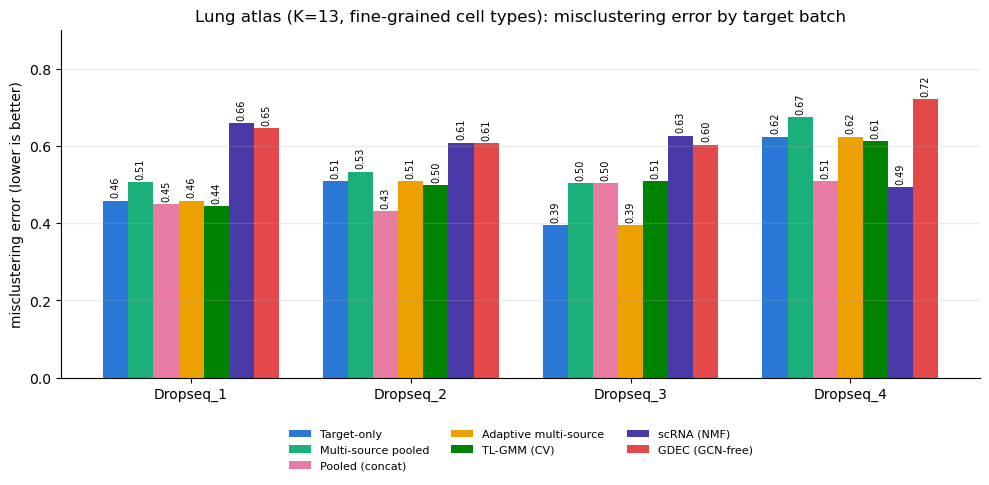

In [6]:
METHOD_COLORS = {
    "target_only": "#2a78d6",
    "multi_source_pooled": "#1baf7a",
    "pooled_concat": "#e87ba4",
    "adaptive_multi_source": "#eda100",
    "tlgmm": "#008300",
    "scrna": "#4a3aa7",
    "gdec_gcnfree": "#e34948",
}
METHOD_ORDER = list(common.METHOD_LABELS.keys())

pivot = results.pivot(index="method", columns="target", values="misclustering").reindex(
    index=METHOD_ORDER, columns=common.BATCHES
)

n_methods = len(METHOD_ORDER)
x = np.arange(len(common.BATCHES))
width = 0.8 / n_methods

fig, ax = plt.subplots(figsize=(10, 5))
for i, method in enumerate(METHOD_ORDER):
    offset = (i - (n_methods - 1) / 2) * width
    vals = pivot.loc[method].values
    bars = ax.bar(x + offset, vals, width, label=common.METHOD_LABELS[method],
                   color=METHOD_COLORS[method])
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(common.BATCHES)
ax.set_ylabel("misclustering error (lower is better)")
ax.set_title("Lung atlas (K=13, fine-grained cell types): misclustering error by target batch")
ax.set_ylim(0, max(pivot.values.max() * 1.25, 0.05))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=False, fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()

fig_path = os.path.join("results", "lung_atlas_misclustering.pdf")
fig.savefig(fig_path, bbox_inches="tight")
print(f"Wrote {fig_path}")
plt.show()